<a href="https://colab.research.google.com/github/SUDEEPZ-RAM/Classification-of-speech-categories-from-1-bit-quantized-signals/blob/main/mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Dump-16bit-46

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
numeric = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_numeric.csv"
)

command = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_command.csv"
)

read = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_read.csv"
)

conversation = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_conversation.csv"
)

print("Numeric:", numeric.shape)
print("Command:", command.shape)
print("Read:", read.shape)
print("Conversation:", conversation.shape)

Numeric: (3000, 99)
Command: (3000, 99)
Read: (3000, 99)
Conversation: (3000, 99)


In [4]:
numeric["class"] = 0
command["class"] = 1
read["class"] = 2
conversation["class"] = 3

df = pd.concat(
    [
        numeric,
        command,
        read,
        conversation
    ],
    ignore_index=True
)

print(df.shape)

(12000, 100)


In [5]:
drop_cols = [
    col for col in df.columns
    if col.startswith("delta_") or col.startswith("delta2_")
]

df = df.drop(columns=drop_cols)

In [6]:
remove_cols = []

for col in [
    "filepath",
    "filename",
    "speaker",
    "session",
    "command",
    "digit",
    "label",
    "speech_type",
    "target",
    "class"
]:

    if col in df.columns:
        remove_cols.append(col)

X = df.drop(
    columns=remove_cols
)


print("Features Shape:", X.shape)


Features Shape: (12000, 46)


In [7]:
X = df.drop(columns=["label","class"])

y = df["class"]

print(X.shape)

(12000, 46)


In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    stratify=y_temp,

    random_state=42
)

print(X_train.shape)

print(X_val.shape)

print(X_test.shape)

(9600, 46)
(1200, 46)
(1200, 46)


# 16bit-46 Features

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [10]:
num_classes = 4

y_train_cat = tf.keras.utils.to_categorical(
    y_train,
    num_classes
)

y_val_cat = tf.keras.utils.to_categorical(
    y_val,
    num_classes
)

y_test_cat = tf.keras.utils.to_categorical(
    y_test,
    num_classes
)

In [11]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed fixed:", SEED)

Random seed fixed: 42


In [12]:
model = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(46,)
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        4,
        activation="softmax"
    )

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,252 (67.39 KB)

 Trainable params: 16,868 (65.89 KB)

 Non-trainable params: 384 (1.50 KB)

In [13]:

model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

In [14]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True
)

history = model.fit(

    X_train,

    y_train_cat,

    validation_data=(
        X_val,
        y_val_cat
    ),

    epochs=100,

    batch_size=64,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7085 - loss: 0.7294 - val_accuracy: 0.8517 - val_loss: 0.4274
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8361 - loss: 0.4246 - val_accuracy: 0.8817 - val_loss: 0.3036
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8622 - loss: 0.3604 - val_accuracy: 0.8925 - val_loss: 0.2809
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8770 - loss: 0.3155 - val_accuracy: 0.8975 - val_loss: 0.2655
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8871 - loss: 0.2991 - val_accuracy: 0.9075 - val_loss: 0.2494
Epoch 6/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8954 - loss: 0.2827 - val_accuracy: 0.9050 - val_loss: 0.2387
Epoch 7/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9009 - loss: 0.2647 - val_accuracy: 0.9083 - val_loss: 0.2281
Epoch 8/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9055 - loss: 0.2435 - val_accu

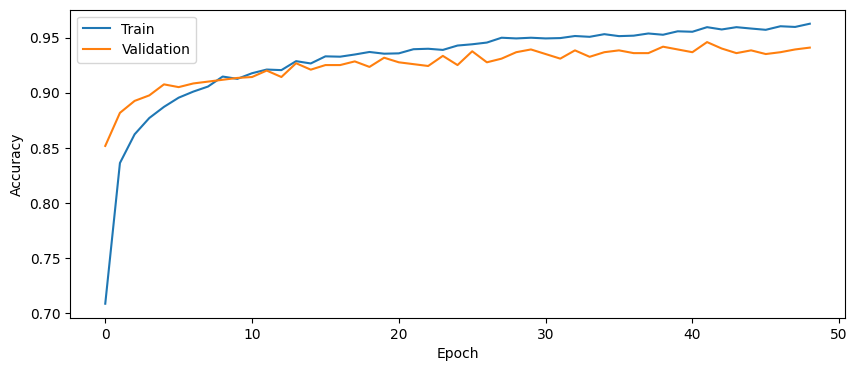

In [15]:
plt.figure(figsize=(10,4))

plt.plot(history.history["accuracy"],label="Train")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [16]:
test_loss,test_acc=model.evaluate(

    X_test,
    y_test_cat,
    verbose=0
)

print("Test Accuracy:",test_acc)

Test Accuracy: 0.949999988079071


In [51]:
import numpy as np
from sklearn.metrics import classification_report

# Define your class names in the correct numeric order
class_names = ["numeric", "command", "read", "conversation"]

# Get predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Print report with target_names
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

     numeric       0.94      1.00      0.97       300
     command       0.81      0.73      0.77       300
        read       0.79      0.77      0.78       300
conversation       0.82      0.88      0.85       300

    accuracy                           0.84      1200
   macro avg       0.84      0.84      0.84      1200
weighted avg       0.84      0.84      0.84      1200



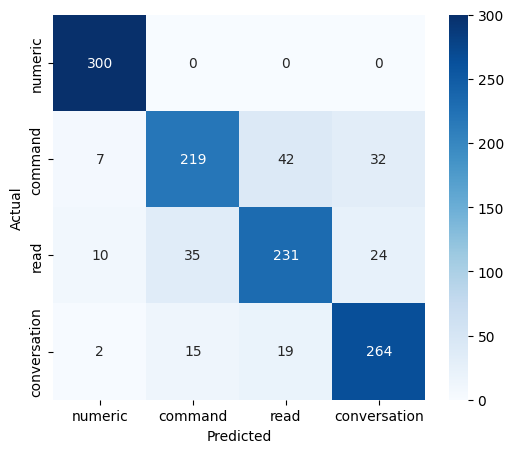

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Define your class names in the correct numeric order (0 to 3)
class_names = ["numeric", "command", "read", "conversation"]

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

# Add xticklabels and yticklabels to show the names
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [19]:
train_loss, train_acc = model.evaluate(X_train, y_train_cat, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")

Train Accuracy      : 0.9777
Validation Accuracy : 0.9417
Test Accuracy       : 0.9500


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# ==========================================================
# Predictions
# ==========================================================

y_prob = model.predict(X_test)

y_pred = np.argmax(y_prob, axis=1)

# ==========================================================
# Accuracy
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

# ==========================================================
# Precision
# ==========================================================

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

# ==========================================================
# Recall
# ==========================================================

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

# ==========================================================
# F1 Score
# ==========================================================

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

macro_f1 = f1

# ==========================================================
# ROC-AUC
# ==========================================================

roc_auc = roc_auc_score(
    y_test_cat,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# ==========================================================
# Equal Error Rate (EER)
# ==========================================================

eer_list = []

for i in range(4):

    fpr, tpr, thresholds = roc_curve(
        y_test_cat[:, i],
        y_prob[:, i]
    )

    fnr = 1 - tpr

    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]

    eer_list.append(eer)

eer = np.mean(eer_list)

# ==========================================================
# Print Metrics
# ==========================================================

print("="*50)
print("MLP Performance-16bit")
print("="*50)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall (Macro)     : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Equal Error Rate   : {eer:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MLP Performance-16bit
Accuracy           : 0.9500
Precision (Macro)  : 0.9500
Recall (Macro)     : 0.9500
F1 Score           : 0.9498
ROC-AUC            : 0.9949
Macro F1           : 0.9498
Equal Error Rate   : 0.0317


In [21]:
print("Epochs Trained :", len(history.history["loss"]))

Epochs Trained : 49


# Data Dump-1bit

In [22]:
numeric = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_numeric.csv"
)

command = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_command.csv"
)

read = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_read.csv"
)

conversation = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_conversation.csv"
)

print("Numeric:", numeric.shape)
print("Command:", command.shape)
print("Read:", read.shape)
print("Conversation:", conversation.shape)

Numeric: (3000, 99)
Command: (3000, 99)
Read: (3000, 99)
Conversation: (3000, 99)


In [23]:
numeric["class"] = 0
command["class"] = 1
read["class"] = 2
conversation["class"] = 3

df = pd.concat(
    [
        numeric,
        command,
        read,
        conversation
    ],
    ignore_index=True
)

print(df.shape)

(12000, 100)


In [24]:
drop_cols = [
    col for col in df.columns
    if col.startswith("delta_") or col.startswith("delta2_")
]

df = df.drop(columns=drop_cols)

In [25]:
remove_cols = []

for col in [
    "filepath",
    "filename",
    "speaker",
    "session",
    "command",
    "digit",
    "label",
    "speech_type",
    "target"
]:

    if col in df.columns:
        remove_cols.append(col)

X = df.drop(
    columns=remove_cols
)


print("Features Shape:", X.shape)


Features Shape: (12000, 47)


In [26]:
X = df.drop(columns=["label","class"])

y = df["class"]

print(X.shape)

(12000, 46)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    stratify=y_temp,

    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(9600, 46)
(1200, 46)
(1200, 46)


# 1bit-46 features

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [54]:
import tensorflow as tf

num_classes = 4

y_train_cat = tf.keras.utils.to_categorical(
    y_train,
    num_classes
)

y_val_cat = tf.keras.utils.to_categorical(
    y_val,
    num_classes
)

y_test_cat = tf.keras.utils.to_categorical(
    y_test,
    num_classes
)

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
tf.keras.backend.clear_session()
model = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(46,)
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        4,
        activation="softmax"
    )

])

model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,252 (67.39 KB)

 Trainable params: 16,868 (65.89 KB)

 Non-trainable params: 384 (1.50 KB)

In [56]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True
)

history = model.fit(

    X_train,

    y_train_cat,

    validation_data=(
        X_val,
        y_val_cat
    ),

    epochs=100,

    batch_size=64,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5760 - loss: 1.0280 - val_accuracy: 0.6933 - val_loss: 0.7493
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6950 - loss: 0.7343 - val_accuracy: 0.7450 - val_loss: 0.6097
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7356 - loss: 0.6399 - val_accuracy: 0.7708 - val_loss: 0.5466
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7558 - loss: 0.5963 - val_accuracy: 0.7858 - val_loss: 0.5255
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7733 - loss: 0.5586 - val_accuracy: 0.7892 - val_loss: 0.5117
Epoch 6/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7848 - loss: 0.5351 - val_accuracy: 0.8025 - val_loss: 0.4846
Epoch 7/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7969 - loss: 0.5146 - val_accuracy: 0.8092 - val_loss: 0.4828
Epoch 8/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8033 - loss: 0.4960 - val_accu

In [57]:
train_loss, train_acc = model.evaluate(
    X_train,
    y_train_cat,
    verbose=0
)

val_loss, val_acc = model.evaluate(
    X_val,
    y_val_cat,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")

Train Accuracy      : 0.8915
Validation Accuracy : 0.8417
Test Accuracy       : 0.8408


In [61]:
import numpy as np
from sklearn.metrics import classification_report

# Define your class names in the correct numeric order
class_names = ["numeric", "command", "read", "conversation"]

# Get predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Print report with target_names
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

     numeric       0.95      0.99      0.97       300
     command       0.80      0.74      0.77       300
        read       0.78      0.78      0.78       300
conversation       0.82      0.85      0.84       300

    accuracy                           0.84      1200
   macro avg       0.84      0.84      0.84      1200
weighted avg       0.84      0.84      0.84      1200



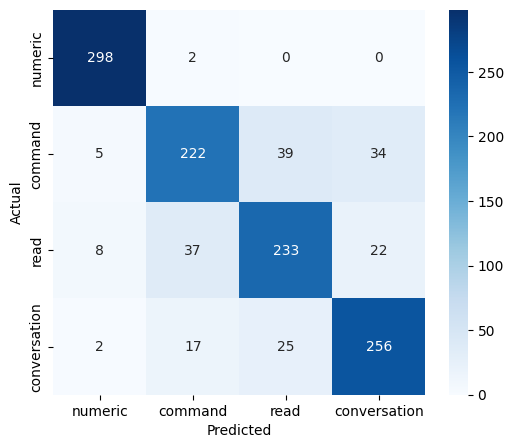

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Define your class names in the correct numeric order (0 to 3)
class_names = ["numeric", "command", "read", "conversation"]

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

# Add xticklabels and yticklabels to show the names
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# ==========================================================
# Predictions
# ==========================================================

y_prob = model.predict(X_test)

y_pred = np.argmax(y_prob, axis=1)

# ==========================================================
# Accuracy
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

# ==========================================================
# Precision
# ==========================================================

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

# ==========================================================
# Recall
# ==========================================================

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

# ==========================================================
# F1 Score
# ==========================================================

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

macro_f1 = f1

# ==========================================================
# ROC-AUC
# ==========================================================

roc_auc = roc_auc_score(
    y_test_cat,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# ==========================================================
# Equal Error Rate (EER)
# ==========================================================

eer_list = []

for i in range(4):

    fpr, tpr, thresholds = roc_curve(
        y_test_cat[:, i],
        y_prob[:, i]
    )

    fnr = 1 - tpr

    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]

    eer_list.append(eer)

eer = np.mean(eer_list)

# ==========================================================
# Print Metrics
# ==========================================================

print("="*50)
print("MLP Performance-1bit")
print("="*50)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall (Macro)     : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Equal Error Rate   : {eer:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MLP Performance-1bit
Accuracy           : 0.8408
Precision (Macro)  : 0.8389
Recall (Macro)     : 0.8408
F1 Score           : 0.8394
ROC-AUC            : 0.9679
Macro F1           : 0.8394
Equal Error Rate   : 0.0867


In [60]:
print("Epochs Trained :", len(history.history["loss"]))

Epochs Trained : 36
